In [ ]:
import warnings
warnings.filterwarnings('ignore')

# 1. Load the PDF document
from langchain_community.document_loaders import PyPDFLoader
loader = PyPDFLoader('economics_research_reference.pdf')
pages = loader.load()

# 2. Split the document into chunks for embedding/retrieval
from langchain_text_splitters import RecursiveCharacterTextSplitter
splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=150)
chunk_fun = splitter.split_documents(pages)
chunk = [i.page_content for i in chunk_fun]
metadata = [i.metadata for i in chunk_fun]
metadata[0]

{'producer': 'ReportLab PDF Library - (opensource)',
 'creator': '(unspecified)',
 'creationdate': '2026-07-18T06:07:24+00:00',
 'author': 'Study and Research Compendium',
 'keywords': '',
 'moddate': '2026-07-18T06:07:24+00:00',
 'subject': '(unspecified)',
 'title': 'Economics: A Unified Research Reference',
 'trapped': '/False',
 'source': 'economics_research_reference.pdf',
 'total_pages': 11,
 'page': 0,
 'page_label': '1'}

In [ ]:
# 3. Set up Chroma vector store with sentence-transformer embeddings
import chromadb
from chromadb.utils.embedding_functions import SentenceTransformerEmbeddingFunction
embedding = SentenceTransformerEmbeddingFunction(model_name='all-MiniLM-L6-v2')

client = chromadb.PersistentClient(path='./chroma')
collection = client.get_or_create_collection(name='collection', embedding_function=embedding)

if collection.count() == 0:
    collection.add(
        documents=chunk,
        ids=[str(i) for i in range(len(chunk))],
        metadatas=metadata
    )
collection.count()    

31

In [ ]:
# 4. Set up the Groq LLM
import os
from dotenv import load_dotenv
load_dotenv()
key = os.getenv('GROQ_API_KEY')
from langchain_groq import ChatGroq
llm = ChatGroq(model='openai/gpt-oss-120b', temperature=0, api_key=key)
llm

# 5. Calculator tool
import numexpr
from langchain_core.tools import tool

@tool
def calculator(expression:str):
    '''This tool is useful for arithmetic operation'''
    try:
        respponse = numexpr.evaluate(expression)
        return str (respponse)
    except Exception as e:
        return str (e)


In [ ]:
# 6. Define the graph state
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from typing import Annotated,TypedDict

class state(TypedDict):
    messages : Annotated[list,add_messages]

In [ ]:
# 7. Retrieval node
def retrive(state:state):
    query = state['messages'][-1].content
    prompt = f'Rewrite this for semantic search: {query}'
    query_rewrite = llm.invoke(prompt)
    query_rewrite = query_rewrite.content
    
    result = collection.query(query_texts=[query_rewrite], n_results=8)
    distance = result['distances'][0]
    document = result['documents'][0]
    threshold = 1.0
    good_chunk = []
    for doc, dist in zip(document, distance):
        if threshold > dist:
            good_chunk.append(doc)
    if not good_chunk:
        content = 'This is not my content'  
    else:           
        content = '\n\n'.join(good_chunk)
        return {'messages':content}

# 8. Chatbot (LLM) node
def chatbot(state:state):
    return {'messages':llm.invoke(state['messages'])}    

In [ ]:
# 9. Tool-calling setup
tool = [calculator]
llm_tool = llm.bind_tools(tool)
def tool_calls(state:state):
    response = llm_tool.invoke(state['messages'])
    return{'messages':[response]}

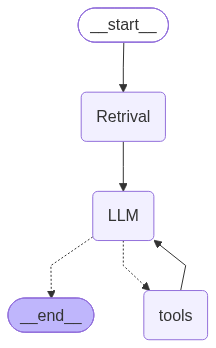

In [ ]:
# 10. Build the graph
from langgraph.prebuilt import tools_condition, ToolNode

building = StateGraph(state)

building.add_node('Retrival',retrive)
building.add_node('LLM',chatbot)
building.add_node('tools',ToolNode(tool))

building.add_edge(START,'Retrival')
building.add_edge('Retrival','LLM')
building.add_conditional_edges('LLM',tools_condition)
building.add_edge('tools','LLM')

graph = building.compile()
graph

In [ ]:
# 11. Run the graph
from langchain_core.messages import HumanMessage
response = graph.invoke({
    'messages': [
        HumanMessage(content='what is 100*2-57')
    ]
})
response['messages'][-1].content

'The expression evaluates to:\n\n\\[\n100 \\times 2 - 57 = 200 - 57 = \\boxed{143}\n\\]'